In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')
import arviz as az
import pymc as pm
#from main_pool import Main
#from calibr_funcs import plot_results
import calibr_funcs
from networks.model_output import SEIRModelOutput, SEIRParams
from networks.SEIR_network import SEIRNetworkModel
import scipy.stats as stats
from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data
from source.autoencoder import AESurrogateModel
#pip install -e git+https://github.com/Mpkosh/Mathematics-of-Epidemics-on-Networks.git@my_changes#egg=eon

import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
%load_ext autoreload
%autoreload 2

pm.__version__  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'5.25.1'

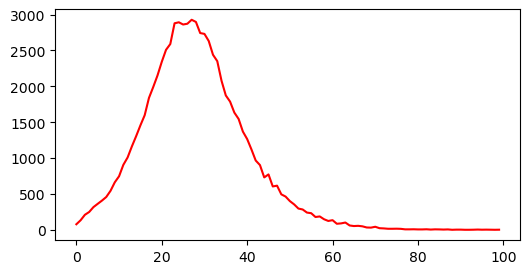

In [2]:
'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
plt.subplots(figsize=(6,3))

observed_data = pd.read_csv('incidence_synthetic_curve.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)

plt.plot(observed_data,color='red')


0.15128829480425082 0.8855652941232486
[0]


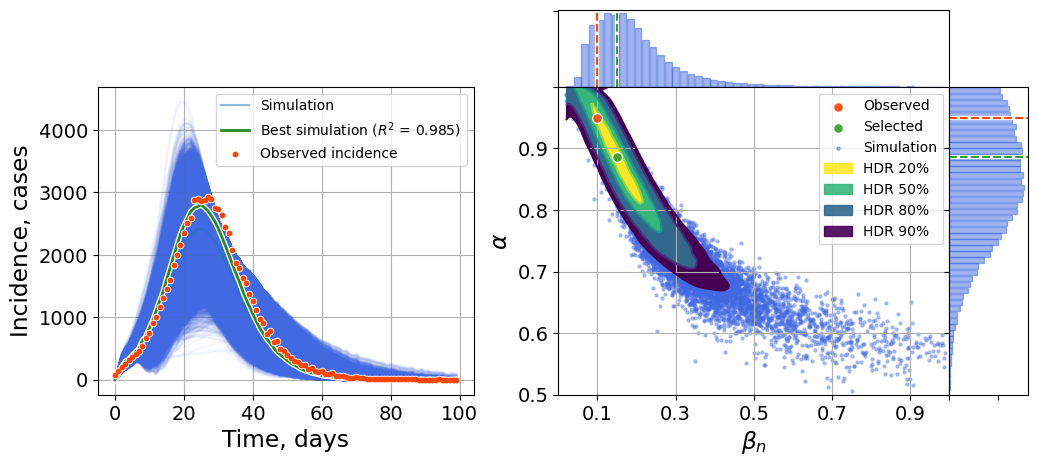

In [4]:
with_switch=np.array(False) 
with_df=[False]
num_runs=[0]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

idata = az.from_netcdf(f"ba_surr.nc")

plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params)


In [167]:
df_c

,town_name,cld_year,week_number,qty_lt15,wd_lt15,qty_total,qty_15,wd_total,wd_15,years_part,yp_week
1030,Архангельск,2009,40,49907.0,1610.0,354682.0,304775.0,2569.0,959.0,20092010,1.0
1031,Архангельск,2009,41,49907.0,1364.0,354682.0,304775.0,2201.0,837.0,20092010,2.0
1032,Архангельск,2009,42,49907.0,1535.0,354682.0,304775.0,2279.0,744.0,20092010,3.0
1033,Архангельск,2009,43,49907.0,1635.0,354682.0,304775.0,2312.0,677.0,20092010,4.0
1034,Архангельск,2009,44,49907.0,1627.0,354682.0,304775.0,2406.0,779.0,20092010,5.0
...,...,...,...,...,...,...,...,...,...,...,...
82378,Якутск,2019,16,74218.0,3422.0,338582.0,264364.0,3931.0,509.0,20182019,29.0
82379,Якутск,2019,17,74218.0,2832.0,338582.0,264364.0,3227.0,395.0,20182019,30.0
82380,Якутск,2019,18,74218.0,2186.0,338582.0,264364.0,2447.0,261.0,20182019,31.0
82381,Якутск,2019,19,74218.0,2065.0,338582.0,264364.0,2343.0,278.0,20182019,32.0


In [168]:
df_c = pd.read_excel('../network_hybrid_33/sum_intensity/data1990_2019.xlsx')
df_c = df_c[(df_c.cld_year >= 2009)&(df_c.cld_year < 2020)]

# qty_total - qty_15
# remove people older than 15, because children's data has less underreporting
df_c['qty_lt15'] = df_c['qty_total'] - df_c['qty_15']
df_c['wd_lt15'] = df_c['wd_total'] - df_c['wd_15']

# we combine [40w:52w] year x  AND  [0w:20w] year x+1
df_c = df_c[~((df_c.cld_year == 2009)&(df_c.week_number < 40))]
df_c = df_c[~((df_c.cld_year == 2019)&(df_c.week_number > 40))]
df_c = df_c[((df_c.week_number >= 40)|(df_c.week_number <= 39))]
df_c = df_c[['town_name','cld_year','week_number','qty_lt15','wd_lt15','qty_total','qty_15','wd_total','wd_15']]
df_c['years_part'] = ''
ntowns = df_c.town_name.nunique()
df_c = df_c[df_c.week_number!=53]
nweeks =  df_c.week_number.nunique()

for i in np.arange(2009,2019):
    df_c.loc[((df_c.cld_year == i)&(df_c.week_number >=40)
             )|((df_c.cld_year == i+1)&(df_c.week_number <=39)),
             'years_part'] = f'{i}{i+1}'
    df_c.loc[((df_c.cld_year == i)&(df_c.week_number >=40)
             )|((df_c.cld_year == i+1)&(df_c.week_number <=39)),
             'yp_week'] = [*np.arange(1,nweeks+1)]*ntowns
    
df_c.head()

,town_name,cld_year,week_number,qty_lt15,wd_lt15,qty_total,qty_15,wd_total,wd_15,years_part,yp_week
1030,Архангельск,2009,40,49907.0,1610.0,354682.0,304775.0,2569.0,959.0,20092010,1.0
1031,Архангельск,2009,41,49907.0,1364.0,354682.0,304775.0,2201.0,837.0,20092010,2.0
1032,Архангельск,2009,42,49907.0,1535.0,354682.0,304775.0,2279.0,744.0,20092010,3.0
1033,Архангельск,2009,43,49907.0,1635.0,354682.0,304775.0,2312.0,677.0,20092010,4.0
1034,Архангельск,2009,44,49907.0,1627.0,354682.0,304775.0,2406.0,779.0,20092010,5.0


<Axes: xlabel='yp_week', ylabel='wd_total'>

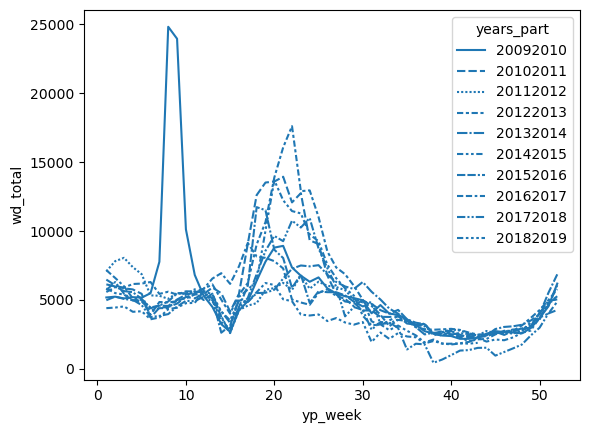

In [169]:
sns.lineplot(x = df_c[df_c.town_name=='Самара'].yp_week,
            y = df_c[df_c.town_name=='Самара'].wd_total, 
             style=df_c[df_c.town_name=='Самара'].years_part)

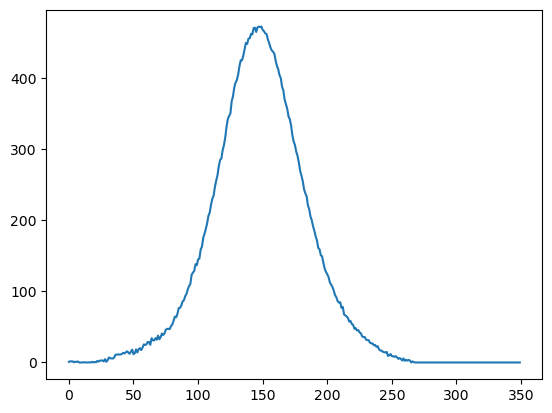

In [69]:
model = AESurrogateModel(10**5, 'sw')
q = model.simulate(0.5,0.6)
q[q<0] = 0
plt.plot(q)

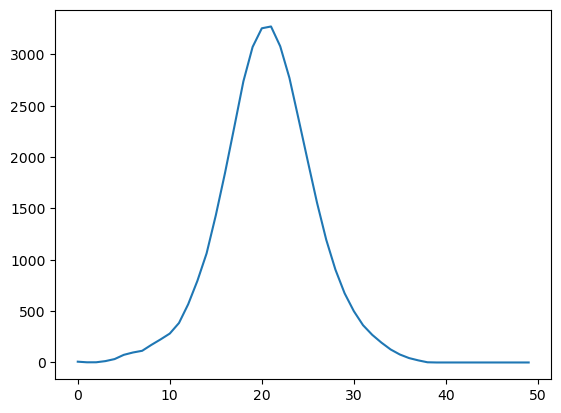

In [94]:
plt.plot(pd.Series(q).groupby(pd.Series(q).index // 7).sum() )

In [75]:
pd.Series(q).groupby(pd.Series(q).index // 7).sum().values.shape

(50,)

In [ ]:
week_data

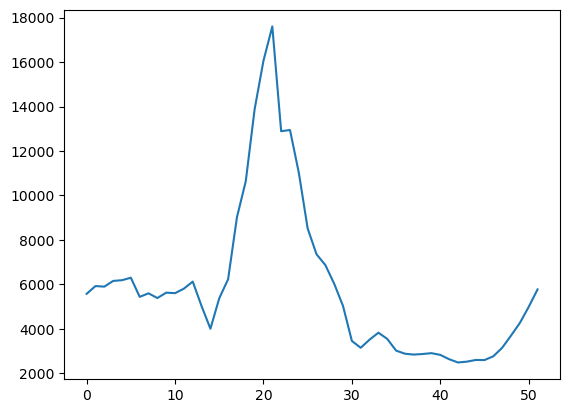

In [170]:
town = 'Самара'
year = 2012
data = df_c[(df_c.town_name==town)&(df_c.years_part==f'{year}{year+1}')]
pop = data.qty_total.mean()
incidence = data.wd_total.values

plt.plot(incidence)

In [174]:
incidence.shape

(52,)

In [178]:
def surr_sim(rng, alpha, beta, modeling_duration, 
             pop, n_nodes, top,
            size=None):
    modeling_duration = modeling_duration[0]
    pop = pop[0]
    n_nodes =n_nodes[0]
    top =top[0]
    
    koeff = 1 #(pop/n_nodes)
    if top:
        top_str = 'ba'
    else:
        top_str = 'sw'
    model = AESurrogateModel(10**5, top_str)
    #alpha, beta
    q = model.simulate(alpha,beta)
    
    q[q<0] = 0
    week_data = pd.Series(q).groupby(pd.Series(q).index // 7).sum().values
    
    diff_w = week_data.shape[0] - modeling_duration
    # если меньше -- добавляем нули
    if diff_w < 0:
        week_data = [*week_data,*[0]*abs(diff_w)]
    else:
        week_data = week_data[:modeling_duration]
        
    return (week_data*koeff)

In [179]:
surr_sim(0, 0.5, 0.6, modeling_duration, 
             [pop], n_nodes, top)
            

[np.float32(7.724768),
 np.float32(1.7433934),
 np.float32(1.981555),
 np.float32(13.282956),
 np.float32(33.049644),
 np.float32(74.29222),
 np.float32(97.29805),
 np.float32(113.90776),
 np.float32(171.42343),
 np.float32(224.80917),
 np.float32(281.75607),
 np.float32(384.71738),
 np.float32(567.4525),
 np.float32(795.1332),
 np.float32(1062.7073),
 np.float32(1433.0784),
 np.float32(1845.678),
 np.float32(2289.1062),
 np.float32(2738.6904),
 np.float32(3072.9426),
 np.float32(3254.915),
 np.float32(3272.5505),
 np.float32(3079.7769),
 np.float32(2771.7808),
 np.float32(2368.911),
 np.float32(1959.3285),
 np.float32(1555.8384),
 np.float32(1195.7083),
 np.float32(904.10657),
 np.float32(673.4717),
 np.float32(499.88562),
 np.float32(363.09525),
 np.float32(269.0776),
 np.float32(193.23436),
 np.float32(126.64838),
 np.float32(77.67673),
 np.float32(42.843975),
 np.float32(20.57143),
 np.float32(1.9707127),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.f

In [180]:
# 851.69
draws = 2
chains = 1
progressbar = True


epsilon=2000
gamma = [0.3]
delta=[0.2]
n_nodes=[100000]
top = [False] #is BA?
modeling_duration = [incidence.shape[0]]

new_observed = incidence

with pm.Model() as pm_modelp:
    real_data = pm.Data("incidence", new_observed)
    alpha = pm.Uniform(name="alpha", lower=10/n_nodes[0], upper=1.)
    beta = pm.Uniform(name="tau", lower=0., upper=1.)
    
    # вынесем, тк для прогноза нужно будет задавать размер
    print(alpha, beta, modeling_duration, 
             [pop], n_nodes, top)
    
    sim = pm.Simulator("sim", surr_sim, 
                        params = (alpha, beta, 
                                  modeling_duration, 
                                  [pop], n_nodes, top
                                 ),   
                       
                        epsilon=epsilon, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=new_observed
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idatap = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()


# It took  32616.331862449646 sec
print('It took ', end_time-start_time, 'sec')


idata = idatap.copy()

idata.sample_stats = idata.sample_stats.drop('beta')
idata.sample_stats = idata.sample_stats.drop('log_marginal_likelihood')
idata.sample_stats = idata.sample_stats.drop('accept_rate')
idata.to_netcdf(f"surr_on_real/ba_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")


Initializing SMC sampler...
Sampling 1 chain in 1 job


alpha tau [52] [np.float64(1170081.5)] [100000] [False]


The number of samples is too small to check convergence reliably.


It took  5.203735113143921 sec


'surr_on_real/ba_surr_2_1_eps2000_g0.3_d0.2.nc'

In [182]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\user\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 483, in superreload
    module = reload(module)
  File "C:\Users\user\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


ValueError: Contour levels must be increasing

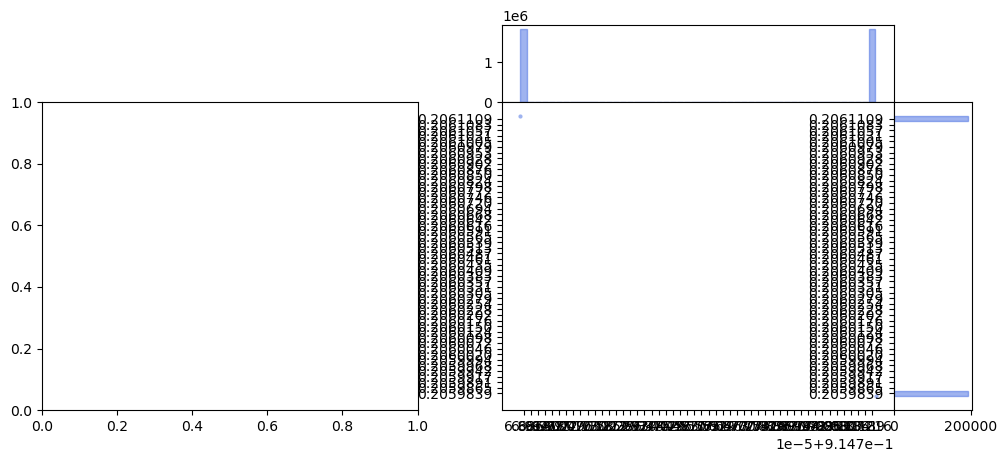

In [159]:
idatat = az.from_netcdf(f"surr_on_real/ba_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")
network_params=[False,0,0,gamma,delta,n_nodes]
plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params, pred=False)